In [1]:
from ipywidgets import HBox, VBox, Box, fixed, interactive_output
from plotly.graph_objects import FigureWidget
from IPython.display import display
from pycaret.classification import setup, compare_models, plot_model

import pandas as pd
import plotly.express as px
import sys
import os

sys.path.append(os.path.abspath("./"))
import helpers as _

In [29]:
df = pd.read_csv('Followchon/data/df_detections_t.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')
df['hour'] = pd.to_numeric(df['hour'])
df

,datetime,date,hour,zone,zone_id,class,class_index,T
0,2024-07-21 13:18:01,2024-07-21,13,Clapier,1.0,Noisette,1,NaN
1,2024-07-21 13:19:07,2024-07-21,13,NaN,NaN,Noisette,1,NaN
2,2024-07-21 13:19:15,2024-07-21,13,Cachette,2.0,Stitch,2,NaN
3,2024-07-21 13:19:16,2024-07-21,13,NaN,NaN,Stitch,2,NaN
4,2024-07-21 13:22:12,2024-07-21,13,NaN,NaN,Noisette,1,NaN
...,...,...,...,...,...,...,...,...
53469,2024-11-19 09:34:01,2024-11-19,9,Cachette,2.0,Noisette,1,NaN
53470,2024-11-19 09:41:01,2024-11-19,9,Foin,16.0,Noisette,1,NaN
53471,2024-11-19 09:41:01,2024-11-19,9,Cachette,2.0,Noisette,1,NaN
53472,2024-11-19 09:41:01,2024-11-19,9,NaN,NaN,Noisette,1,NaN


In [30]:
classes = ['Noisette', 'Stitch']
zones = ['Clapier', 'Fontaine', 'Loft', 'Cachette', 'Foin']

mask = (df['hour'].between(9, 19)
    & df['zone'].str.contains('|'.join(zones)))

df_filterd = df.loc[mask, ['datetime', 'date', 'hour', 'T', 'zone', 'class']]
df_filterd

,datetime,date,hour,T,zone,class
0,2024-07-21 13:18:01,2024-07-21,13,NaN,Clapier,Noisette
2,2024-07-21 13:19:15,2024-07-21,13,NaN,Cachette,Stitch
5,2024-07-21 13:22:16,2024-07-21,13,NaN,Cachette,Noisette
6,2024-07-21 13:23:10,2024-07-21,13,NaN,Cachette,Stitch
11,2024-07-21 13:30:05,2024-07-21,13,NaN,Cachette,Stitch
...,...,...,...,...,...,...
53468,2024-11-19 09:34:01,2024-11-19,9,NaN,Clapier,Noisette
53469,2024-11-19 09:34:01,2024-11-19,9,NaN,Cachette,Noisette
53470,2024-11-19 09:41:01,2024-11-19,9,NaN,Foin,Noisette
53471,2024-11-19 09:41:01,2024-11-19,9,NaN,Cachette,Noisette


In [38]:
classes_encoded = [f'class_{c}' for c in classes]
zones_encoded = [f'zone_{c}' for c in zones]

print(classes_encoded)
print(zones_encoded)

df_encoded = pd.get_dummies(df_filterd, columns=['class'])
df_encoded.to_csv('Followchon/data/df_detections_t_encoded.csv')
df_encoded

['class_Noisette', 'class_Stitch']
['zone_Clapier', 'zone_Fontaine', 'zone_Loft', 'zone_Cachette', 'zone_Foin']


,datetime,date,hour,T,zone,class_Noisette,class_Stitch
0,2024-07-21 13:18:01,2024-07-21,13,NaN,Clapier,True,False
2,2024-07-21 13:19:15,2024-07-21,13,NaN,Cachette,False,True
5,2024-07-21 13:22:16,2024-07-21,13,NaN,Cachette,True,False
6,2024-07-21 13:23:10,2024-07-21,13,NaN,Cachette,False,True
11,2024-07-21 13:30:05,2024-07-21,13,NaN,Cachette,False,True
...,...,...,...,...,...,...,...
53468,2024-11-19 09:34:01,2024-11-19,9,NaN,Clapier,True,False
53469,2024-11-19 09:34:01,2024-11-19,9,NaN,Cachette,True,False
53470,2024-11-19 09:41:01,2024-11-19,9,NaN,Foin,True,False
53471,2024-11-19 09:41:01,2024-11-19,9,NaN,Cachette,True,False


In [39]:
exp = setup( data=df_encoded[['datetime', 'date', 'hour', 'T', 'zone'] + classes_encoded], target="zone", session_id=42, remove_outliers=True )

,Description,Value
0,Session id,42
1,Target,zone
2,Target type,Multiclass
3,Target mapping,"Cachette: 0, Clapier: 1, Foin: 2, Fontaine: 3, Loft: 4"
4,Original data shape,"(23960, 7)"
5,Transformed data shape,"(23137, 11)"
6,Transformed train set shape,"(15949, 11)"
7,Transformed test set shape,"(7188, 11)"
8,Numeric features,2
9,Date features,2


In [40]:
model = compare_models(exclude=[])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.4942,0.7384,0.4942,0.4798,0.4704,0.2811,0.2875,10.5930
et,Extra Trees Classifier,0.4874,0.7278,0.4874,0.4719,0.4678,0.2747,0.2793,0.5780
rf,Random Forest Classifier,0.4859,0.7305,0.4859,0.4720,0.4711,0.2805,0.2834,0.6840
dt,Decision Tree Classifier,0.4850,0.7225,0.4850,0.4690,0.4658,0.2724,0.2767,0.2160
gbc,Gradient Boosting Classifier,0.4682,0.0000,0.4682,0.4546,0.4198,0.2183,0.2346,2.7610
knn,K Neighbors Classifier,0.4593,0.6896,0.4593,0.4417,0.4415,0.2359,0.2391,0.2590
ada,Ada Boost Classifier,0.4010,0.0000,0.4010,0.3393,0.3243,0.0971,0.1123,0.4710
ridge,Ridge Classifier,0.3954,0.0000,0.3954,0.2344,0.2719,0.0352,0.0553,0.2210
lda,Linear Discriminant Analysis,0.3949,0.0000,0.3949,0.2429,0.2756,0.0378,0.0577,0.2200
qda,Quadratic Discriminant Analysis,0.3929,0.0000,0.3929,0.1544,0.2217,0.0000,0.0000,0.2190


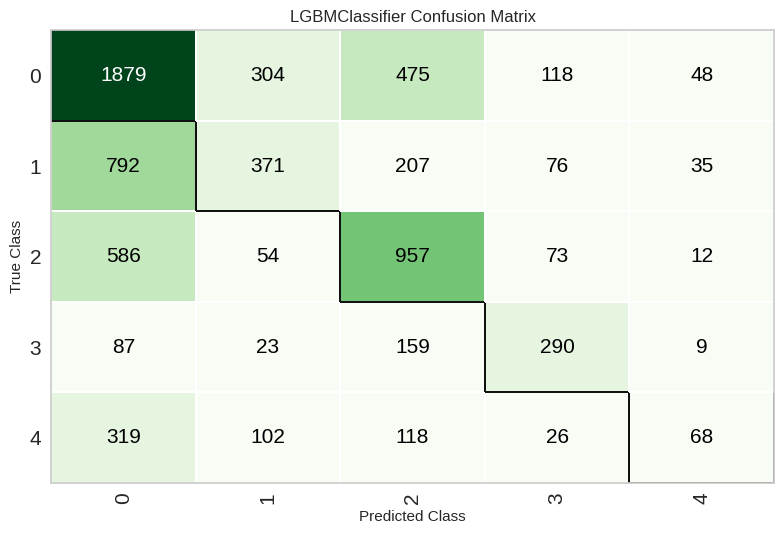

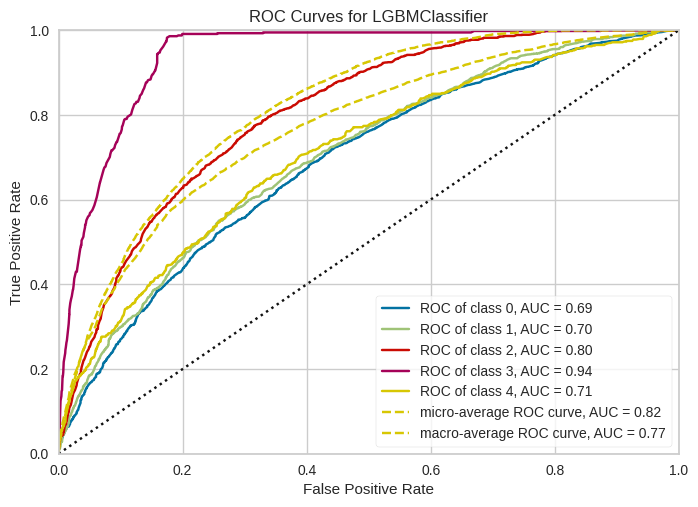

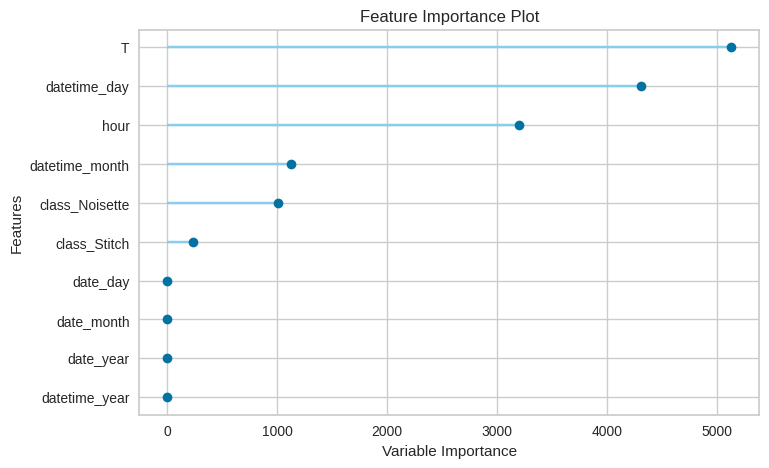

In [41]:
plot_model(model, plot='confusion_matrix')
plot_model(model, plot='auc')
plot_model(model,'feature')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4911,0.7410,0.4911,0.4798,0.4745,0.2832,0.2868
1,0.5060,0.7458,0.5060,0.4898,0.4844,0.2965,0.3022
2,0.4753,0.7278,0.4753,0.4537,0.4516,0.2551,0.2598
3,0.4937,0.7388,0.4937,0.4746,0.4730,0.2850,0.2895
4,0.4854,0.7268,0.4854,0.4637,0.4640,0.2746,0.2787
5,0.4848,0.7271,0.4848,0.4705,0.4631,0.2679,0.2737
6,0.4764,0.7304,0.4764,0.4570,0.4586,0.2669,0.2697
7,0.5033,0.7442,0.5033,0.5002,0.4878,0.2960,0.3014
8,0.5212,0.7521,0.5212,0.5072,0.5010,0.3205,0.3265


Fitting 10 folds for each of 10 candidates, totalling 100 fits


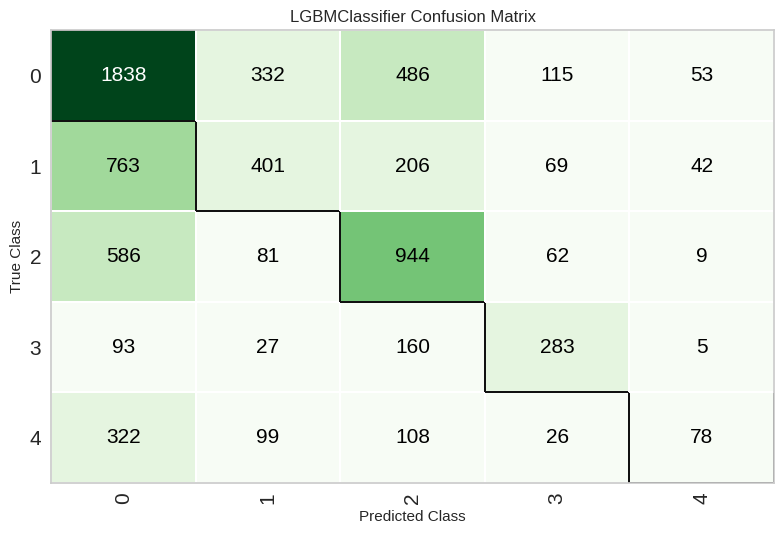

In [42]:
model_tuned = tune_model(model)
plot_model(model_tuned, plot='confusion_matrix')

In [43]:
top_5_models = compare_models(n_select=5, exclude=[])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.4942,0.7384,0.4942,0.4798,0.4704,0.2811,0.2875,8.1400
et,Extra Trees Classifier,0.4874,0.7278,0.4874,0.4719,0.4678,0.2747,0.2793,0.5610
rf,Random Forest Classifier,0.4859,0.7305,0.4859,0.4720,0.4711,0.2805,0.2834,0.6900
dt,Decision Tree Classifier,0.4850,0.7225,0.4850,0.4690,0.4658,0.2724,0.2767,0.2460
gbc,Gradient Boosting Classifier,0.4682,0.0000,0.4682,0.4546,0.4198,0.2183,0.2346,2.8750
knn,K Neighbors Classifier,0.4593,0.6896,0.4593,0.4417,0.4415,0.2359,0.2391,0.2570
ada,Ada Boost Classifier,0.4010,0.0000,0.4010,0.3393,0.3243,0.0971,0.1123,0.4700
ridge,Ridge Classifier,0.3954,0.0000,0.3954,0.2344,0.2719,0.0352,0.0553,0.2210
lda,Linear Discriminant Analysis,0.3949,0.0000,0.3949,0.2429,0.2756,0.0378,0.0577,0.2310
qda,Quadratic Discriminant Analysis,0.3929,0.0000,0.3929,0.1544,0.2217,0.0000,0.0000,0.2190


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5018,0.7404,0.5018,0.4909,0.4827,0.2949,0.3003
1,0.4994,0.7440,0.4994,0.4874,0.4829,0.2933,0.2976
2,0.4770,0.7237,0.4770,0.4565,0.4525,0.2544,0.2602
3,0.4919,0.7373,0.4919,0.4762,0.4720,0.2856,0.2899
4,0.4908,0.7306,0.4908,0.4736,0.4695,0.2796,0.2847
5,0.4753,0.7242,0.4753,0.4579,0.4516,0.2564,0.2617
6,0.4729,0.7283,0.4729,0.4533,0.4518,0.2566,0.2606
7,0.4961,0.7426,0.4961,0.4834,0.4770,0.2853,0.2907
8,0.5110,0.7489,0.5110,0.4933,0.4908,0.3092,0.3141


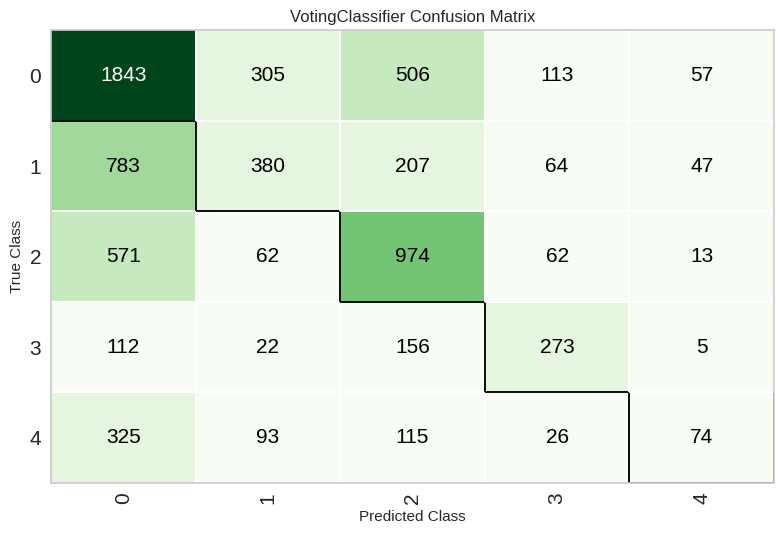

In [44]:
blended_model = blend_models(top_5_models)
plot_model(blended_model, plot='confusion_matrix')